# Chapter 5 — Classification with Deep Learning
## Practical Statistics for Data Scientists, 2nd Edition

Chapter 5 membahas **classification**, termasuk probability score, confusion matrix, precision/recall, ROC-AUC, dan imbalanced data. Struktur sumber tetap menjadi dasar, tetapi implementasi di notebook ini difokuskan pada **Deep Neural Network (DNN)**, bukan metode ML klasik. citeturn0search0

**Data:** synthetic binary-classification data, dibuat reproducible untuk demonstrasi.


## 1. Tujuan Pembelajaran
- Memahami binary classification dalam Deep Learning.
- Menyiapkan data train/validation/test.
- Membangun DNN dengan TensorFlow/Keras.
- Memahami ReLU, sigmoid, forward propagation, loss, backpropagation, dan Adam.
- Mengevaluasi model dengan confusion matrix, precision, recall, F1, ROC-AUC.
- Memahami threshold, class imbalance, regularization, dan error analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score,precision_recall_curve
np.random.seed(42); tf.random.set_seed(42)
sns.set_theme(style="whitegrid",context="notebook")
plt.rcParams["figure.figsize"]=(9,5)
print("TensorFlow:",tf.__version__)


TensorFlow: 2.20.0


## 2. Classification dalam Deep Learning
Untuk binary classification, target adalah $y\in\{0,1\}$. DNN menghasilkan probability $\hat p=P(y=1|X)$ melalui output sigmoid. Probability kemudian dapat diubah menjadi class menggunakan threshold.


In [2]:
rng=np.random.default_rng(42); n=2400
x1=rng.normal(0,1,n); x2=rng.normal(0,1,n)
score=1.7*x1-1.2*x2+1.8*np.sin(x1*x2)+rng.normal(0,.8,n)
y=(score>.25).astype(int)
data=pd.DataFrame({"Feature_1":x1,"Feature_2":x2,"Target":y})
display(data.head()); print(data.Target.value_counts(normalize=True))


,Feature_1,Feature_2,Target
0,0.304717,-0.446069,1
1,-1.039984,0.980191,0
2,0.750451,0.281173,1
3,0.940565,-0.697557,1
4,-1.951035,-0.865940,0


Target
1    0.528333
0    0.471667
Name: proportion, dtype: float64


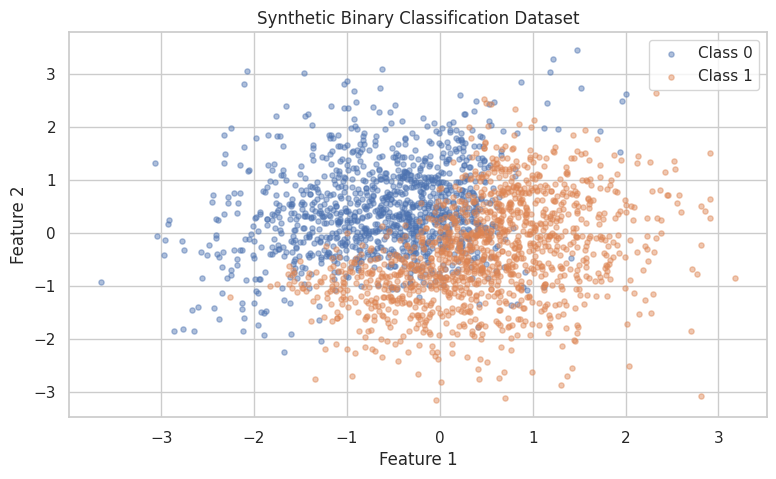

Caption — Dua kelas overlap dan memiliki pola nonlinear, sehingga cocok untuk demonstrasi DNN.


In [3]:
fig,ax=plt.subplots()
for c,label in [(0,"Class 0"),(1,"Class 1")]:
    d=data[data.Target==c]; ax.scatter(d.Feature_1,d.Feature_2,s=14,alpha=.45,label=label)
ax.set(title="Synthetic Binary Classification Dataset",xlabel="Feature 1",ylabel="Feature 2"); ax.legend(); plt.show()
print("Caption — Dua kelas overlap dan memiliki pola nonlinear, sehingga cocok untuk demonstrasi DNN.")


## 3. Train, Validation, dan Test Split
Training digunakan untuk update weights, validation untuk memonitor generalisasi selama training, dan test untuk evaluasi akhir. Standardization hanya fit pada training data untuk menghindari leakage.


In [4]:
X=data[["Feature_1","Feature_2"]].values
y=data.Target.values
Xtr,Xtmp,ytr,ytmp=train_test_split(X,y,test_size=.30,stratify=y,random_state=42)
Xv,Xte,yv,yte=train_test_split(Xtmp,ytmp,test_size=.50,stratify=ytmp,random_state=42)
scaler=StandardScaler(); Xtr=scaler.fit_transform(Xtr); Xv=scaler.transform(Xv); Xte=scaler.transform(Xte)
print("Train",Xtr.shape,"Validation",Xv.shape,"Test",Xte.shape)


Train (1680, 2) Validation (360, 2) Test (360, 2)


## 4. Deep Neural Network Architecture
Arsitektur: **Input(2) → Dense(32, ReLU) → Dense(16, ReLU) → Dropout(20%) → Output(1, Sigmoid)**.

ReLU memberi nonlinear representation pada hidden layers. Sigmoid menghasilkan probability untuk binary classification.


In [5]:
model=tf.keras.Sequential([
 tf.keras.layers.Input(shape=(2,)),
 tf.keras.layers.Dense(32,activation="relu"),
 tf.keras.layers.Dense(16,activation="relu"),
 tf.keras.layers.Dropout(.20),
 tf.keras.layers.Dense(1,activation="sigmoid")])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

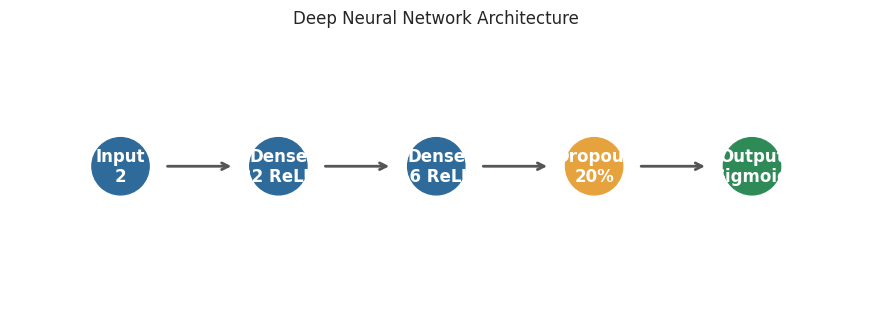

Caption — Hidden layers membentuk representasi nonlinear; sigmoid menghasilkan probability Class 1.


In [6]:
layers=["Input\n2","Dense\n32 ReLU","Dense\n16 ReLU","Dropout\n20%","Output\nSigmoid"]
fig,ax=plt.subplots(figsize=(11,3.5)); xs=np.arange(len(layers))
ax.scatter(xs,[0]*len(xs),s=1700,color=["#2F6B9A","#2F6B9A","#2F6B9A","#E6A23C","#2E8B57"])
for i in range(4): ax.annotate("",(xs[i+1]-.28,0),(xs[i]+.28,0),arrowprops=dict(arrowstyle="->",lw=2,color="#555"))
for x,t in zip(xs,layers): ax.text(x,0,t,ha="center",va="center",color="white",weight="bold")
ax.set_xlim(-.7,4.7); ax.axis("off"); ax.set_title("Deep Neural Network Architecture"); plt.show()
print("Caption — Hidden layers membentuk representasi nonlinear; sigmoid menghasilkan probability Class 1.")


## 5. Activation Functions
**ReLU:** $max(0,x)$ untuk hidden layers.

**Sigmoid:** $1/(1+e^{-x})$ untuk output binary probability.


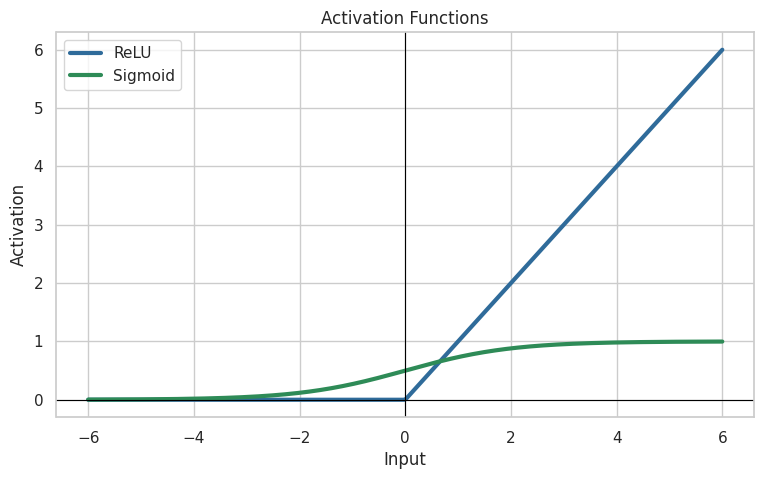

Caption — ReLU menghasilkan representasi nonlinear pada hidden layer; sigmoid memetakan output ke 0–1.


In [7]:
z=np.linspace(-6,6,400); relu=np.maximum(0,z); sig=1/(1+np.exp(-z))
fig,ax=plt.subplots(); ax.plot(z,relu,color="#2F6B9A",lw=3,label="ReLU"); ax.plot(z,sig,color="#2E8B57",lw=3,label="Sigmoid")
ax.axhline(0,color="black",lw=.8); ax.axvline(0,color="black",lw=.8)
ax.set(title="Activation Functions",xlabel="Input",ylabel="Activation"); ax.legend(); plt.show()
print("Caption — ReLU menghasilkan representasi nonlinear pada hidden layer; sigmoid memetakan output ke 0–1.")


## 6. Binary Cross-Entropy Loss
$$L=-[y\log(\hat p)+(1-y)\log(1-\hat p)]$$

Loss menghukum prediction yang salah, terutama ketika model sangat yakin pada kelas yang keliru.


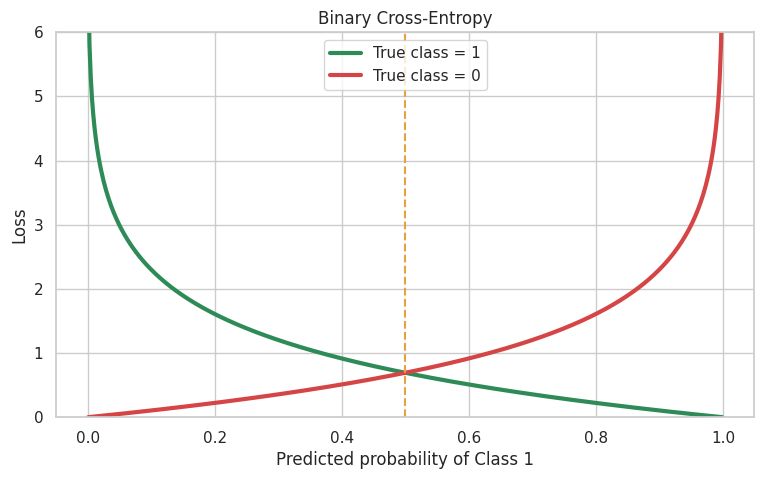

Caption — Loss rendah saat probability mendekati kelas aktual dan meningkat tajam ketika prediction sangat yakin tetapi salah.


In [8]:
pval=np.linspace(.001,.999,500)
fig,ax=plt.subplots(); ax.plot(pval,-np.log(pval),color="#2E8B57",lw=3,label="True class = 1"); ax.plot(pval,-np.log(1-pval),color="#D64545",lw=3,label="True class = 0")
ax.axvline(.5,color="#E6A23C",ls="--"); ax.set_ylim(0,6); ax.set(title="Binary Cross-Entropy",xlabel="Predicted probability of Class 1",ylabel="Loss"); ax.legend(); plt.show()
print("Caption — Loss rendah saat probability mendekati kelas aktual dan meningkat tajam ketika prediction sangat yakin tetapi salah.")


## 7. Training dengan Backpropagation dan Adam
Optimizer Adam memperbarui weights berdasarkan gradient yang diperoleh melalui backpropagation. Early stopping digunakan untuk mengurangi risiko overfitting.


In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=.001),loss="binary_crossentropy",metrics=["accuracy"])
stop=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=12,restore_best_weights=True)
history=model.fit(Xtr,ytr,validation_data=(Xv,yv),epochs=120,batch_size=32,callbacks=[stop],verbose=0)
print("Epochs executed:",len(history.history["loss"]))


Epochs executed: 17


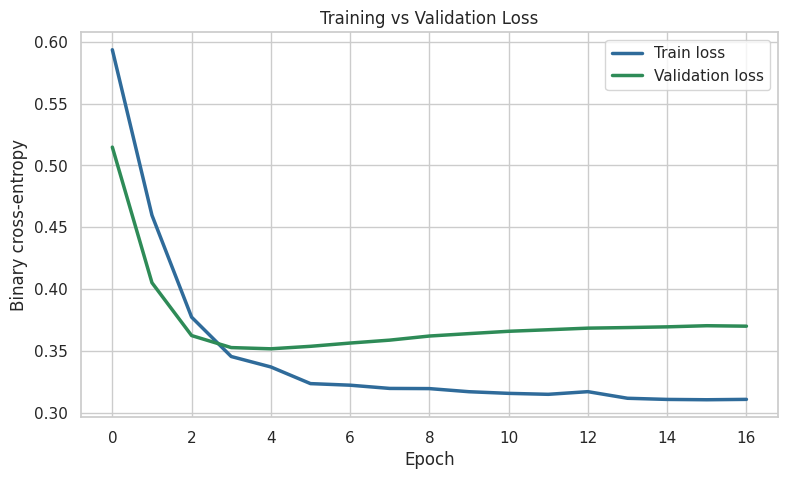

Caption — Validation loss digunakan untuk memonitor generalisasi selama training.


In [10]:
fig,ax=plt.subplots(); ax.plot(history.history["loss"],color="#2F6B9A",lw=2.5,label="Train loss"); ax.plot(history.history["val_loss"],color="#2E8B57",lw=2.5,label="Validation loss")
ax.set(title="Training vs Validation Loss",xlabel="Epoch",ylabel="Binary cross-entropy"); ax.legend(); plt.show()
print("Caption — Validation loss digunakan untuk memonitor generalisasi selama training.")


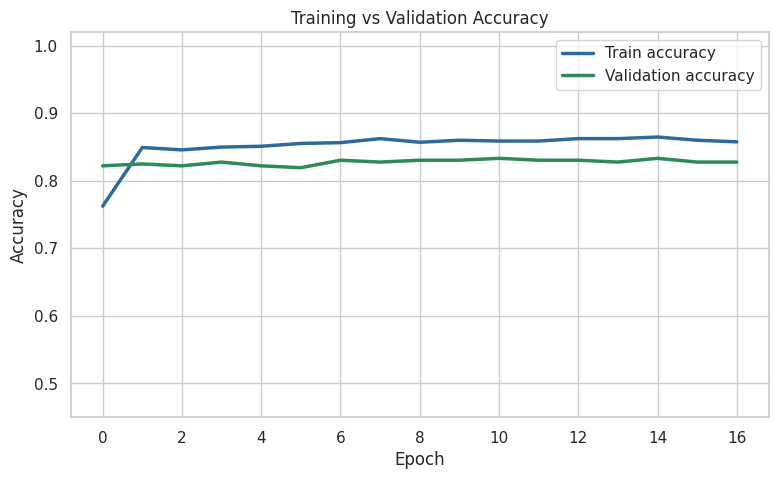

Caption — Gap besar antara training dan validation accuracy dapat mengindikasikan overfitting.


In [11]:
fig,ax=plt.subplots(); ax.plot(history.history["accuracy"],color="#2F6B9A",lw=2.5,label="Train accuracy"); ax.plot(history.history["val_accuracy"],color="#2E8B57",lw=2.5,label="Validation accuracy")
ax.set(title="Training vs Validation Accuracy",xlabel="Epoch",ylabel="Accuracy"); ax.set_ylim(.45,1.02); ax.legend(); plt.show()
print("Caption — Gap besar antara training dan validation accuracy dapat mengindikasikan overfitting.")


## 8. Probability Prediction
Model menghasilkan probability sebelum class decision. Threshold default 0.5 digunakan terlebih dahulu, lalu dianalisis kembali pada bagian threshold analysis.


In [12]:
prob=model.predict(Xte,verbose=0).ravel(); pred=(prob>=.5).astype(int)
display(pd.DataFrame({"Actual":yte[:20],"Probability":np.round(prob[:20],3),"Predicted":pred[:20]}))


,Actual,Probability,Predicted
0,0,0.030,0
1,1,0.733,1
2,1,0.933,1
3,0,0.225,0
4,0,0.026,0
5,0,0.046,0
6,1,0.976,1
7,1,0.809,1
8,0,0.140,0
9,0,0.014,0


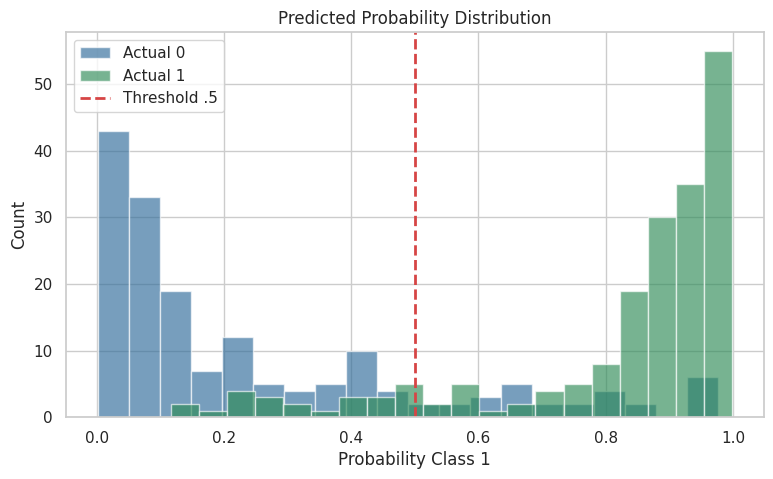

Caption — Overlap probability di sekitar threshold menunjukkan area yang lebih sulit diklasifikasikan.


In [13]:
fig,ax=plt.subplots()
ax.hist(prob[yte==0],bins=20,alpha=.65,color="#2F6B9A",label="Actual 0"); ax.hist(prob[yte==1],bins=20,alpha=.65,color="#2E8B57",label="Actual 1")
ax.axvline(.5,color="#D64545",ls="--",lw=2,label="Threshold .5")
ax.set(title="Predicted Probability Distribution",xlabel="Probability Class 1",ylabel="Count"); ax.legend(); plt.show()
print("Caption — Overlap probability di sekitar threshold menunjukkan area yang lebih sulit diklasifikasikan.")


## 9. Confusion Matrix dan Classification Metrics
Confusion matrix memisahkan TN, FP, FN, dan TP. Dari sini kita menghitung accuracy, precision, recall, specificity, dan F1.


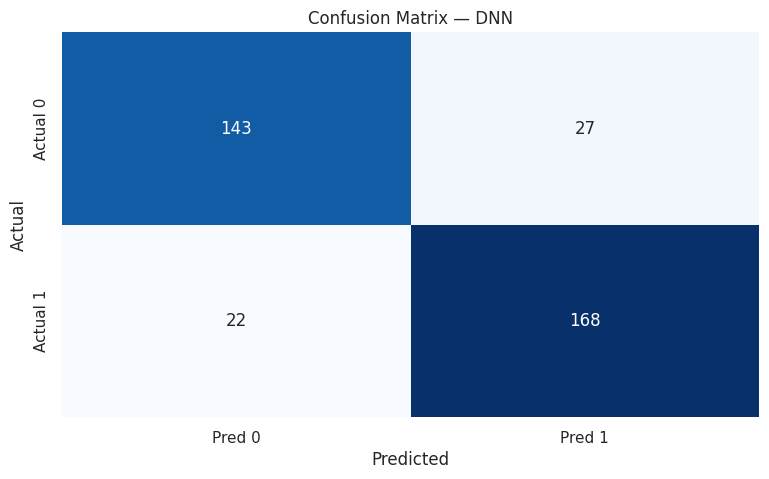

Caption — Diagonal adalah prediction benar; off-diagonal adalah false positive dan false negative.


,Metric,Value
0,Accuracy,0.863889
1,Precision,0.861538
2,Recall,0.884211
3,Specificity,0.841176
4,F1,0.872727


              precision    recall  f1-score   support

           0      0.867     0.841     0.854       170
           1      0.862     0.884     0.873       190

    accuracy                          0.864       360
   macro avg      0.864     0.863     0.863       360
weighted avg      0.864     0.864     0.864       360



In [14]:
cm=confusion_matrix(yte,pred); tn,fp,fn,tp=cm.ravel()
acc=accuracy_score(yte,pred); precision=precision_score(yte,pred,zero_division=0); recall=recall_score(yte,pred,zero_division=0)
specificity=tn/(tn+fp); f1=f1_score(yte,pred,zero_division=0)
fig,ax=plt.subplots(); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,xticklabels=["Pred 0","Pred 1"],yticklabels=["Actual 0","Actual 1"])
ax.set(title="Confusion Matrix — DNN",xlabel="Predicted",ylabel="Actual"); plt.show()
print("Caption — Diagonal adalah prediction benar; off-diagonal adalah false positive dan false negative.")
metrics=pd.DataFrame({"Metric":["Accuracy","Precision","Recall","Specificity","F1"],"Value":[acc,precision,recall,specificity,f1]})
display(metrics); print(classification_report(yte,pred,digits=3))


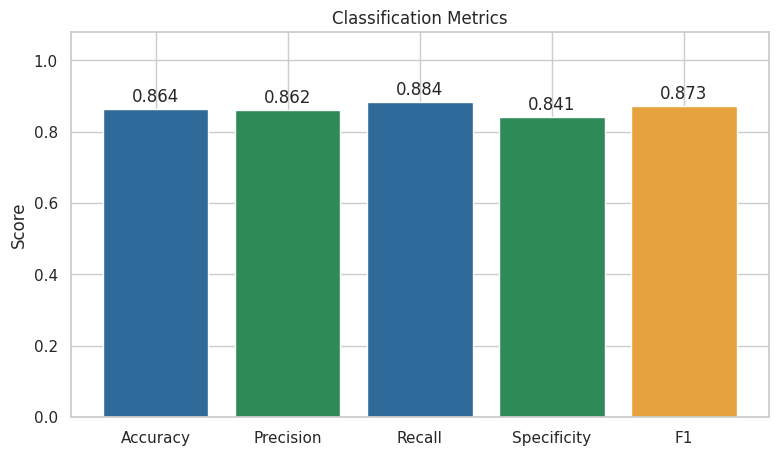

Caption — Accuracy, precision, recall, specificity, dan F1 melihat performa dari perspektif yang berbeda.


In [15]:
fig,ax=plt.subplots(); bars=ax.bar(metrics.Metric,metrics.Value,color=["#2F6B9A","#2E8B57","#2F6B9A","#2E8B57","#E6A23C"])
ax.set_ylim(0,1.08); ax.set(title="Classification Metrics",ylabel="Score")
for b,v in zip(bars,metrics.Value): ax.text(b.get_x()+b.get_width()/2,v+.02,f"{v:.3f}",ha="center")
plt.show(); print("Caption — Accuracy, precision, recall, specificity, dan F1 melihat performa dari perspektif yang berbeda.")


## 10. ROC Curve dan AUC
ROC memperlihatkan trade-off antara True Positive Rate dan False Positive Rate pada berbagai threshold. AUC merangkum kemampuan diskriminasi model.


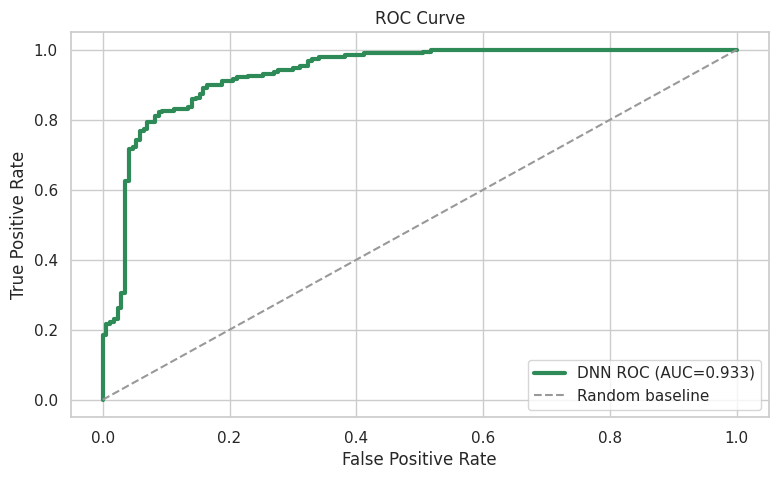

Caption — AUC = 0.933. ROC menunjukkan trade-off performa ketika threshold berubah.


In [16]:
fpr,tpr,_=roc_curve(yte,prob); auc=roc_auc_score(yte,prob)
fig,ax=plt.subplots(); ax.plot(fpr,tpr,color="#2E8B57",lw=3,label=f"DNN ROC (AUC={auc:.3f})"); ax.plot([0,1],[0,1],color="#999",ls="--",label="Random baseline")
ax.set(title="ROC Curve",xlabel="False Positive Rate",ylabel="True Positive Rate"); ax.legend(); plt.show()
print(f"Caption — AUC = {auc:.3f}. ROC menunjukkan trade-off performa ketika threshold berubah.")


## 11. Threshold Analysis
Threshold 0.5 bukan aturan universal. Threshold yang lebih tinggi biasanya membuat positive prediction lebih selektif sehingga precision dan recall dapat berubah.


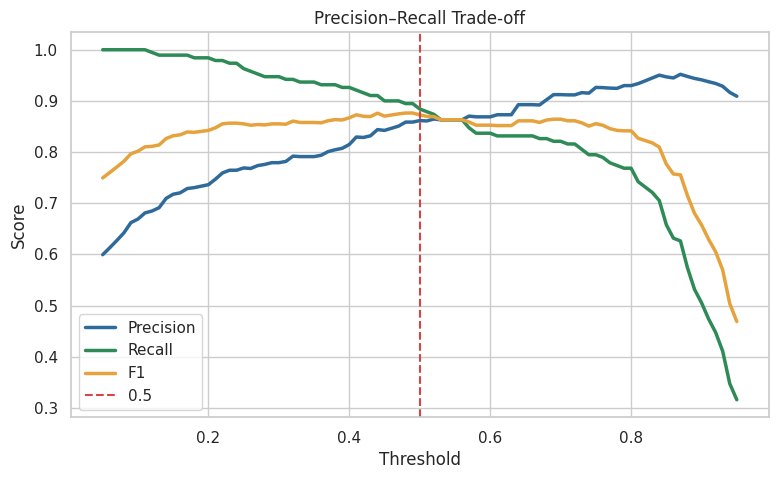

Caption — Threshold mengubah trade-off precision dan recall; pemilihannya perlu mempertimbangkan tujuan aplikasi.


In [17]:
ts=np.linspace(.05,.95,91); rows=[]
for t in ts:
    pp=(prob>=t).astype(int)
    rows.append([t,precision_score(yte,pp,zero_division=0),recall_score(yte,pp,zero_division=0),f1_score(yte,pp,zero_division=0)])
th=pd.DataFrame(rows,columns=["Threshold","Precision","Recall","F1"])
fig,ax=plt.subplots(); ax.plot(th.Threshold,th.Precision,color="#2F6B9A",lw=2.5,label="Precision"); ax.plot(th.Threshold,th.Recall,color="#2E8B57",lw=2.5,label="Recall"); ax.plot(th.Threshold,th.F1,color="#E6A23C",lw=2.5,label="F1")
ax.axvline(.5,color="#D64545",ls="--",label="0.5"); ax.set(title="Precision–Recall Trade-off",xlabel="Threshold",ylabel="Score"); ax.legend(); plt.show()
print("Caption — Threshold mengubah trade-off precision dan recall; pemilihannya perlu mempertimbangkan tujuan aplikasi.")


## 12. Precision–Recall Curve
Precision–recall curve sangat berguna ketika positive class menjadi perhatian utama atau ketika kelas tidak seimbang.


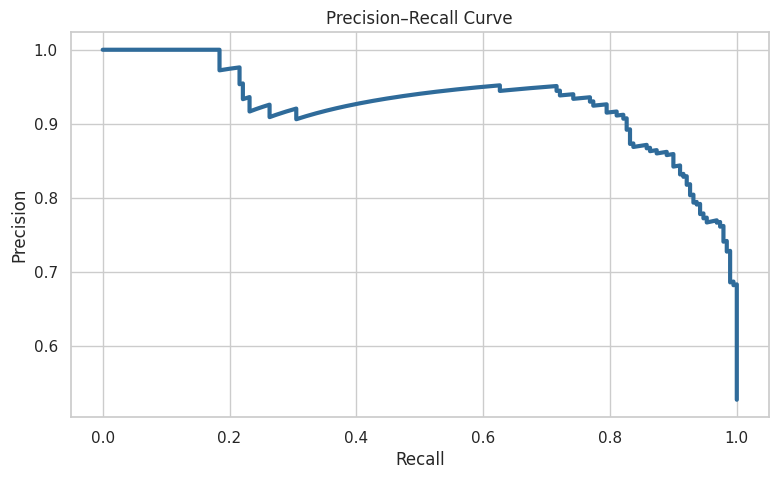

Caption — Kurva menunjukkan trade-off precision dan recall pada berbagai threshold.


In [18]:
pr,rc,_=precision_recall_curve(yte,prob)
fig,ax=plt.subplots(); ax.plot(rc,pr,color="#2F6B9A",lw=3); ax.set(title="Precision–Recall Curve",xlabel="Recall",ylabel="Precision"); plt.show()
print("Caption — Kurva menunjukkan trade-off precision dan recall pada berbagai threshold.")


## 13. Imbalanced Data dan Class Weighting
Accuracy dapat menyesatkan ketika satu kelas jauh lebih banyak. Dalam DL, strategi yang dapat digunakan antara lain class weighting, oversampling training data, threshold adjustment, dan monitoring metric minority class.

Contoh class weighting:
`class_weight={0:1.0, 1:2.0}` lalu diberikan pada `model.fit(..., class_weight=class_weight)`.



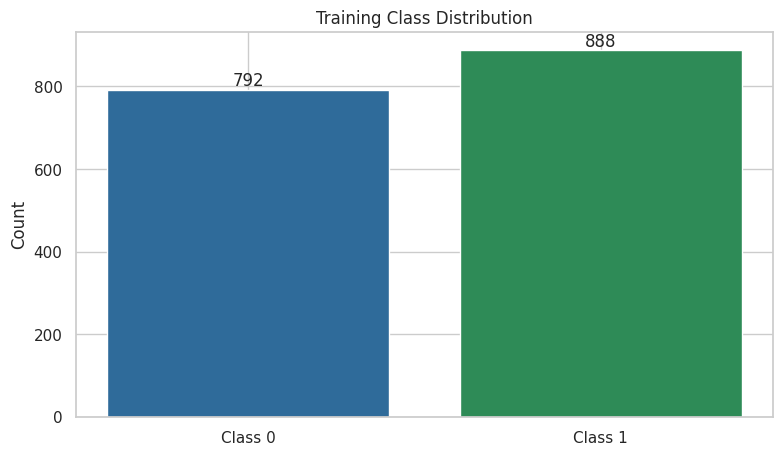

Caption — Distribusi training perlu diperiksa sebelum memilih strategi imbalance.


In [19]:
dist=pd.Series(ytr).value_counts().sort_index()
fig,ax=plt.subplots(); bars=ax.bar(["Class 0","Class 1"],dist.values,color=["#2F6B9A","#2E8B57"])
ax.set(title="Training Class Distribution",ylabel="Count")
for b,v in zip(bars,dist.values): ax.text(b.get_x()+b.get_width()/2,v+10,str(v),ha="center")
plt.show(); print("Caption — Distribusi training perlu diperiksa sebelum memilih strategi imbalance.")


## 14. Error Analysis
Evaluasi agregat perlu dilengkapi dengan pemeriksaan kasus salah prediksi. Lokasi error pada feature space dapat menunjukkan area yang sulit dipelajari.


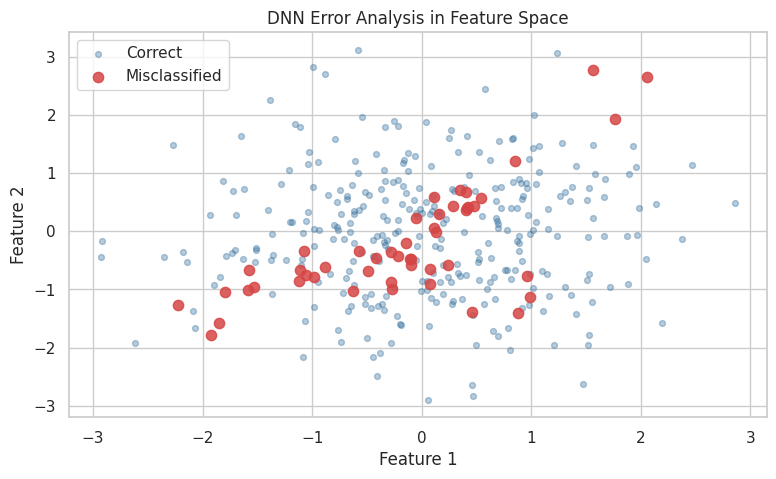

Caption — Titik merah menunjukkan misclassification dan membantu mengidentifikasi area feature space yang sulit dipisahkan.


In [20]:
err=pd.DataFrame({"Feature_1":Xte[:,0],"Feature_2":Xte[:,1],"Actual":yte,"Probability":prob,"Predicted":pred})
err["Correct"]=err.Actual==err.Predicted
fig,ax=plt.subplots(); c=err[err.Correct]; w=err[~err.Correct]
ax.scatter(c.Feature_1,c.Feature_2,s=18,alpha=.35,color="#2F6B9A",label="Correct"); ax.scatter(w.Feature_1,w.Feature_2,s=55,alpha=.85,color="#D64545",label="Misclassified")
ax.set(title="DNN Error Analysis in Feature Space",xlabel="Feature 1",ylabel="Feature 2"); ax.legend(); plt.show()
print("Caption — Titik merah menunjukkan misclassification dan membantu mengidentifikasi area feature space yang sulit dipisahkan.")


## 15. Overfitting dan Regularization
DNN dapat overfit. Notebook menggunakan **Dropout** dan **Early Stopping**. Training/validation curves menjadi diagnosis awal untuk melihat apakah performa validation berhenti membaik sementara training terus membaik.


## 16. Deep Learning Workflow
**Data → preprocessing → train/validation/test → architecture → forward propagation → loss → backpropagation → optimizer update → validation → tuning → test → error analysis**

Workflow ini menempatkan classification sebagai proses DL lengkap, bukan hanya tahap prediction.


## 17. Summary
1. Classification memprediksi kelas dari input features.
2. DNN mempelajari representasi nonlinear melalui hidden layers.
3. ReLU digunakan pada hidden layers dan sigmoid pada binary output.
4. Binary cross-entropy menjadi loss utama.
5. Backpropagation dan Adam memperbarui weights.
6. Validation membantu memonitor generalisasi.
7. Confusion matrix, precision, recall, specificity, F1, dan ROC-AUC memberi evaluasi yang lebih lengkap.
8. Threshold memengaruhi trade-off precision dan recall.
9. Imbalanced data perlu ditangani secara khusus.
10. Error analysis membantu memahami keterbatasan model.

**Takeaway:** tujuan bukan sekadar accuracy tinggi, tetapi DNN yang mampu melakukan generalisasi dan menghasilkan prediction yang dapat dievaluasi serta dipahami.
